# Task 3: Car Price Prediction with Machine Learning

## Objective
Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

## Dataset
Vehicle dataset from Cardekho (Car details v3/kaggle) https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

## Workflow
1. Data loading and understanding
2. Data cleaning
3. Feature engineering
4. Exploratory Data Analysis
5. Feature encoding
6. Train/test split
7. Regression model training
8. Model evaluation
9. Feature importance analysis


In [21]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("outputs/figures", exist_ok=True)

pd.set_option("display.max_columns", None)

## 1. Load Dataset
The dataset is hosted in my GitHub repository and loaded directly using its raw GitHub URL. Original Source: Kaggle

In [22]:
url = "https://raw.githubusercontent.com/SiamWR/OIBSIP/refs/heads/main/DataScience-Task3-CarPricePredictionwithMachineLearning/Dataset/Car%20details%20v3.csv"

df = pd.read_csv(url)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [23]:
print("Dataset Shape:", df.shape)
df.info()

df.describe(include="all")

Dataset Shape: (8128, 13)
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
count,8128,8128.000000,8.128000e+03,8.128000e+03,8128,8128,8128,8128,7907,7907,7913,7906,7907.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,393,121,322,441,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,NaN
freq,129,NaN,NaN,NaN,4402,6766,7078,5289,225,1017,377,530,NaN
mean,NaN,2013.804011,6.382718e+05,6.981951e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.416719
std,NaN,4.044249,8.062534e+05,5.655055e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.959588
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
25%,NaN,2011.000000,2.549990e+05,3.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,2015.000000,4.500000e+05,6.000000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,2017.000000,6.750000e+05,9.800000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


## 2. Data Cleaning

Performed:
- Handle null values
- Remove duplicate records
- Standardize inconsistent categorical values


In [25]:
print("Missing values before cleaning:")
display(df.isnull().sum())

print("Duplicate rows before cleaning:", df.duplicated().sum())

# Remove rows with missing values
required_columns = [
    "name",
    "year",
    "selling_price",
    "mileage",
    "fuel",
    "transmission"
]

df = df.dropna(subset=required_columns)

# Remove duplicate records
df = df.drop_duplicates()

# Standardize categorical values
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = (
        df[col]
        .str.strip()
        .str.title()
    )

print("Dataset Shape after cleaning:", df.shape)

print("Duplicate rows after cleaning:", df.duplicated().sum())


Missing values before cleaning:


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           1
seats            0
dtype: int64

Duplicate rows before cleaning: 0
Dataset Shape after cleaning: (6718, 13)
Duplicate rows after cleaning: 0


C:\Users\88019\AppData\Local\Temp\ipykernel_19104\743465998.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## 3. Feature Engineering

Created features:
- Car age from year column
- Brand from car name column


In [26]:
CURRENT_YEAR = 2026

df["Car_Age"] = CURRENT_YEAR - df["year"]

df["Brand"] = df["name"].str.split().str[0]

# Convert mileage from text to numeric
df["mileage"] = (
    df["mileage"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,Car_Age,Brand
0,Maruti Swift Dzire Vdi,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248 Cc,74 Bhp,190Nm@ 2000Rpm,5.0,12,Maruti
1,Skoda Rapid 1.5 Tdi Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 Cc,103.52 Bhp,250Nm@ 1500-2500Rpm,5.0,12,Skoda
2,Honda City 2017-2020 Exi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497 Cc,78 Bhp,"12.7@ 2,700(Kgm@ Rpm)",5.0,20,Honda
3,Hyundai I20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396 Cc,90 Bhp,22.4 Kgm At 1750-2750Rpm,5.0,16,Hyundai
4,Maruti Swift Vxi Bsiii,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298 Cc,88.2 Bhp,"11.5@ 4,500(Kgm@ Rpm)",5.0,19,Maruti


## 4. Exploratory Data Analysis (EDA)

Required visualizations:
- Selling price distribution
- Price vs fuel type
- Price vs car age


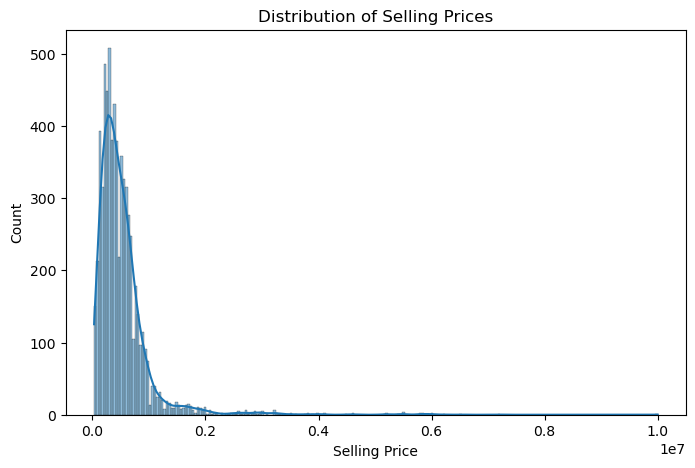

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.savefig("outputs/figures/selling_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

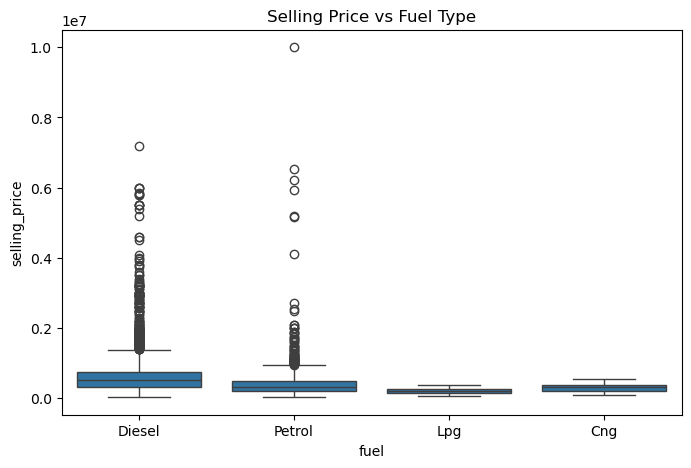

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.title("Selling Price vs Fuel Type")
plt.savefig("outputs/figures/price_vs_fuel_type.png", dpi=300, bbox_inches="tight")
plt.show()

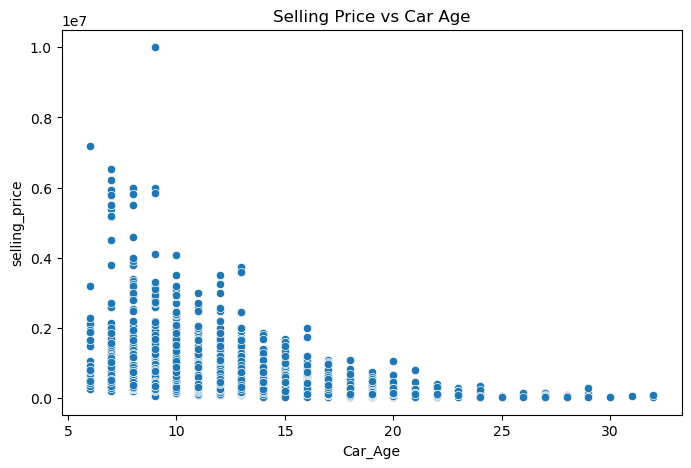

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Car_Age", y="selling_price")
plt.title("Selling Price vs Car Age")
plt.savefig("outputs/figures/price_vs_car_age.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Feature Correlation Heatmap

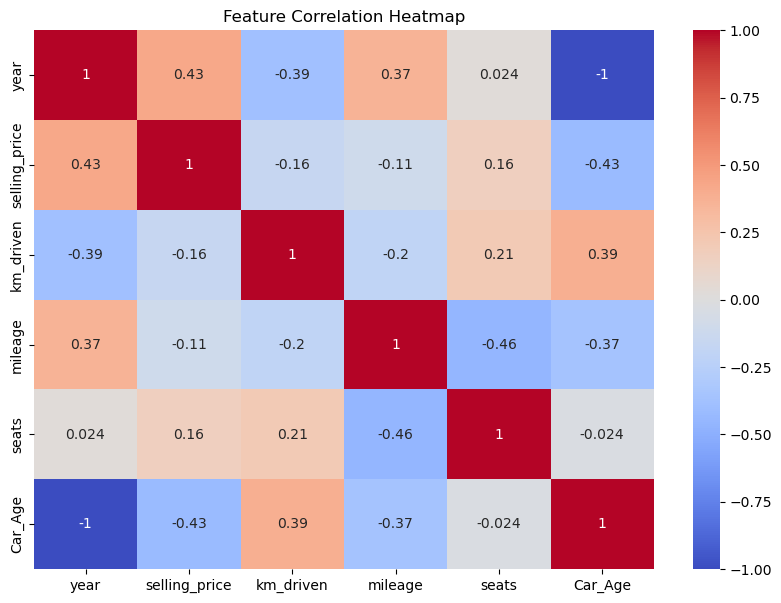

In [30]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Prepare Features and Target

Selected features based on:
- Project objective
- Domain relevance
- Dataset availability

Features:
- Brand
- Car Age
- Mileage
- Kilometers driven
- Fuel type
- Transmission
- Seller type
- Owner
- Engine
- Max power
- Seats


In [31]:
# Convert additional numeric text features

df["engine"] = df["engine"].str.extract(r"(\d+)")[0].astype(float)
df["max_power"] = df["max_power"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

selected_features = [
    "Brand",
    "Car_Age",
    "mileage",
    "km_driven",
    "fuel",
    "transmission",
    "seller_type",
    "owner",
    "engine",
    "max_power",
    "seats"
]

model_df = df[selected_features + ["selling_price"]].dropna()

X = model_df[selected_features]
y = model_df["selling_price"]

X.head()

,Brand,Car_Age,mileage,km_driven,fuel,transmission,seller_type,owner,engine,max_power,seats
0,Maruti,12,23.40,145500,Diesel,Manual,Individual,First Owner,1248.0,74.00,5.0
1,Skoda,12,21.14,120000,Diesel,Manual,Individual,Second Owner,1498.0,103.52,5.0
2,Honda,20,17.70,140000,Petrol,Manual,Individual,Third Owner,1497.0,78.00,5.0
3,Hyundai,16,23.00,127000,Diesel,Manual,Individual,First Owner,1396.0,90.00,5.0
4,Maruti,19,16.10,120000,Petrol,Manual,Individual,First Owner,1298.0,88.20,5.0


## 7. Encode Categorical Variables and Train/Test Split

In [32]:
categorical_features = X.select_dtypes(include="object").columns
numeric_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

C:\Users\88019\AppData\Local\Temp\ipykernel_19104\1910790132.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


## 8. Regression Models

Models:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor


In [33]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    trained_models[name] = pipeline

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2 Score": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,167741.837818,262514.046306,0.685944
1,Random Forest,74173.754299,123927.556323,0.930010
2,Gradient Boosting,83507.624011,131583.498168,0.921095


## 9. Best Model Selection

In [34]:
best_model_name = results_df.sort_values(
    by="R2 Score",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Performing Model:", best_model_name)

Best Performing Model: Random Forest


## 10. Feature Importance Chart

Feature importance is generated for the best-performing tree-based model.
For Linear Regression, absolute coefficients can be interpreted instead.


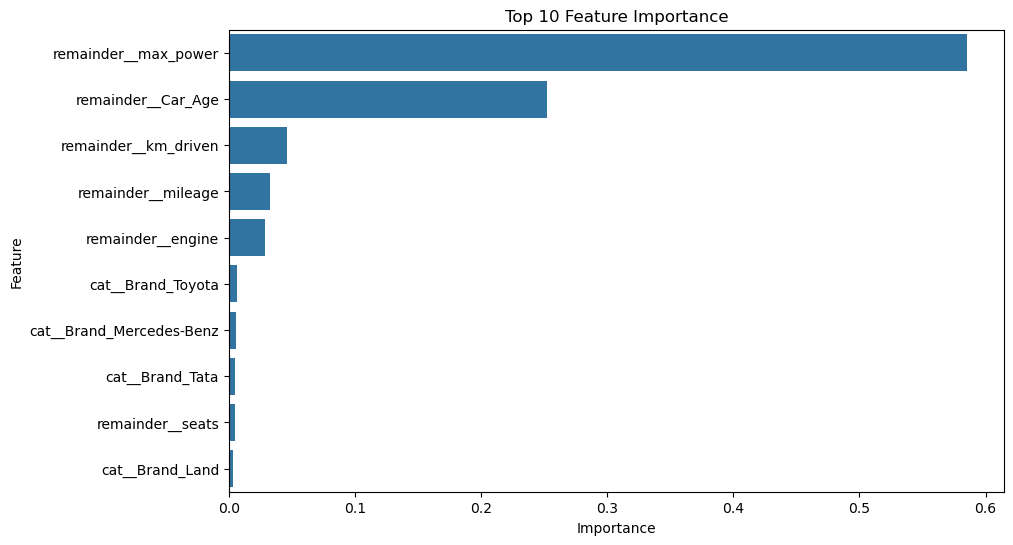

In [35]:
model = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
else:
    importance_values = np.abs(model.coef_)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.savefig("outputs/figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

This project developed a machine learning model to predict used car selling prices.

The workflow included data cleaning, feature engineering, exploratory data analysis, categorical encoding, regression model training, and performance evaluation using MAE, RMSE, and R² score.

Multiple regression models were compared, and the best-performing model is "RandomForestRegressor", was selected based on evaluation results.